In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

# Load data
df = pd.read_csv("data/chicago_crime_data/chicago_crimes_2001_2025.csv", low_memory=False)
print(f"Shape: {df.shape}")
print(df.head())

Shape: (8504790, 22)
         id case_number                     date                     block  \
0  13246664    JG467702  2001-01-01T00:00:00.000  045XX N CENTRAL PARK AVE   
1  13714017    JH548973  2001-01-01T00:00:00.000        051XX W MEDILL AVE   
2  13714063    JH548896  2001-01-01T00:00:00.000        051XX W MEDILL AVE   
3   1310933     G001704  2001-01-01T00:00:00.000         0000X W WACKER DR   
4   1432149     G156662  2001-01-01T00:00:00.000       002XX E DELAWARE PL   

   iucr                primary_type                             description  \
0  0281     CRIMINAL SEXUAL ASSAULT                          NON-AGGRAVATED   
1  1751  OFFENSE INVOLVING CHILDREN  CRIMINAL SEXUAL ABUSE BY FAMILY MEMBER   
2  1751  OFFENSE INVOLVING CHILDREN  CRIMINAL SEXUAL ABUSE BY FAMILY MEMBER   
3  0810                       THEFT                               OVER $500   
4  2825               OTHER OFFENSE                 HARASSMENT BY TELEPHONE   

             location_description  

In [4]:
print(f"Year range: {df['year'].min()} - {df['year'].max()}")
print(f"\nYear distribution:")
print(df['year'].value_counts().sort_index())

Year range: 2001 - 2026

Year distribution:
year
2001    485958
2002    486831
2003    475999
2004    469443
2005    453788
2006    448198
2007    437108
2008    427216
2009    392866
2010    370566
2011    352052
2012    336374
2013    307612
2014    275880
2015    264887
2016    269959
2017    269286
2018    269147
2019    261702
2020    212700
2021    209656
2022    239999
2023    263278
2024    259007
2025    236558
2026     28720
Name: count, dtype: int64


In [8]:
import requests
import pandas as pd
import time
import os
import json

# ── Config ────────────────────────────────────────────────────────────────────
APP_TOKEN    = "H9ETY0ZCsP5vHUqNI6NE2FKG5"
BASE_URL     = "https://data.cityofchicago.org/resource/ijzp-q8t2.json"
BATCH_SIZE   = 50000
BASE_DIR     = os.getcwd()
OUTPUT_DIR   = os.path.join(BASE_DIR, "data", "chicago_crime_data")
FINAL_OUTPUT = os.path.join(OUTPUT_DIR, "chicago_crimes_2001_2025.csv")
PROGRESS_FILE = os.path.join(OUTPUT_DIR, "progress.json")
BATCH_DIR    = os.path.join(OUTPUT_DIR, "batches")
os.makedirs(BATCH_DIR, exist_ok=True)

EXPECTED_COLUMNS = [
    'id', 'case_number', 'date', 'block', 'iucr', 'primary_type',
    'description', 'location_description', 'arrest', 'domestic', 'beat',
    'district', 'ward', 'community_area', 'fbi_code', 'year', 'updated_on',
    'x_coordinate', 'y_coordinate', 'latitude', 'longitude', 'location'
]

def align_columns(df):
    for col in EXPECTED_COLUMNS:
        if col not in df.columns:
            df[col] = None
    return df[EXPECTED_COLUMNS]

def load_data(parquet_path=None, csv_path=None):
    parquet_path = parquet_path or os.path.join(OUTPUT_DIR, "chicago_crimes_cleaned.parquet")
    csv_path = csv_path or FINAL_OUTPUT
    if os.path.exists(parquet_path):
        print("Loading from parquet...")
        return pd.read_parquet(parquet_path)
    if os.path.exists(csv_path):
        print("Loading from CSV...")
        return pd.read_csv(csv_path, low_memory=False)
    raise FileNotFoundError("No data found.")

In [ ]:
H9ETY0ZCsP5vHUqNI6NE2FKG5

In [2]:
# Load the data

df = pd.read_csv("data/chicago_crime_data/chicago_crimes_2001_2025.csv", low_memory = False)

HERE I WILL START AGAIN


In [3]:
import pandas as pd

df = pd.read_parquet("data/chicago_crime_data/chicago_crimes_2001_2025.parquet")

df.head()

ArrowInvalid: Could not open Parquet input source '<Buffer>': Parquet file size is 0 bytes

In [4]:
# Check the basic info of data

print(df.describe())
print(df.shape)          # rows and columns
print(df.dtypes)         # data types
print(df.columns.tolist()) # column names

                 id          beat      district          ward  community_area  \
count  8.476070e+06  8.476070e+06  8.476023e+06  7.861252e+06    7.862385e+06   
mean   7.556887e+06  1.183327e+03  1.129599e+01  2.278741e+01    3.737305e+01   
std    3.804702e+06  7.037585e+02  6.964312e+00  1.385922e+01    2.154745e+01   
min    6.340000e+02  1.110000e+02  1.000000e+00  1.000000e+00    0.000000e+00   
25%    4.088515e+06  6.210000e+02  6.000000e+00  1.000000e+01    2.300000e+01   
50%    7.554550e+06  1.034000e+03  1.000000e+01  2.300000e+01    3.200000e+01   
75%    1.096821e+07  1.731000e+03  1.700000e+01  3.400000e+01    5.600000e+01   
max    1.412427e+07  2.535000e+03  3.100000e+01  5.000000e+01    7.700000e+01   

               year  x_coordinate  y_coordinate      latitude     longitude  
count  8.476070e+06  8.381409e+06  8.381409e+06  8.381409e+06  8.381409e+06  
mean   2.011093e+03  1.164663e+06  1.885920e+06  4.184256e+01 -8.767126e+01  
std    7.136615e+00  1.694813e+04  3

In [16]:
# Filter the data from 2001 to 2025

df = pd.read_csv(FINAL_OUTPUT, low_memory=False)
df = df[df['year'].between(2001, 2025)]
df.to_csv(FINAL_OUTPUT, index=False)
print(df['year'].value_counts().sort_index())
print(f"\nTotal records (2001-2025): {len(df)}")

NameError: name 'FINAL_OUTPUT' is not defined

COMENCEMOS UNA VEZ MAS

In [17]:
# Trabajando sobre el df que YA tienes en memoria
df_2001_2025 = df[df['year'].between(2001, 2025)]

In [2]:


df = pd.read_parquet("data/chicago_crime_data/chicago_2001_2025.parquet")

# Vamos a inicair desde aca el analisis

In [20]:


# Asegura nombres consistentes
df.columns = [c.strip().lower() for c in df.columns]

# Filtra rango de estudio
df_y = df[df['year'].between(2001, 2025)].copy()

# Agrega por distrito y año
df_yearly = (
    df_y.groupby(['district', 'year'])
        .agg(
            crimes=('id', 'count'),
            arrests=('arrest', 'sum')
        )
        .reset_index()
        .sort_values(['district', 'year'])
)

# Ejemplo: crear lag de arrestos (para disuasión con FE o regresión simple)
df_yearly['arrests_lag1'] = df_yearly.groupby('district')['arrests'].shift(1)

df_yearly.head()

,district,year,crimes,arrests,arrests_lag1
0,1.0,2001,14865,4421,NaN
1,1.0,2002,17974,6226,4421.0
2,1.0,2003,17571,6603,6226.0
3,1.0,2004,17579,6501,6603.0
4,1.0,2005,17700,7224,6501.0


In [22]:
'date' in df.columns
# y, si existe:
df['date'].head().tolist()

['2001-01-01T00:00:00.000',
 '2001-01-01T00:00:00.000',
 '2001-01-01T00:00:00.000',
 '2001-01-01T00:00:00.000',
 '2001-01-01T00:00:00.000']

In [23]:

# Solo si 'date' existe:
df['date'] = pd.to_datetime(
    df['date'],
    format="%m/%d/%Y %I:%M:%S %p",   # ajusta si ves que no calza
    errors="coerce"
)

# Comprueba que no haya demasiados NaT:
df['date'].isna().mean()


np.float64(1.0)

In [24]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')


In [25]:
# Filtro temporal
mask = df['year'].between(2001, 2025)

df_m = (
    df[mask]
      .dropna(subset=['date'])
      .groupby(['district', pd.Grouper(key='date', freq='MS')])  # inicio de mes
      .agg(
          crimes=('id', 'count'),
          arrests=('arrest', 'sum')
      )
      .reset_index()
      .rename(columns={'date': 'month'})
      .sort_values(['district', 'month'])
)

# Lag de arrestos (para modelos de disuasión)
df_m['arrests_lag1'] = df_m.groupby('district')['arrests'].shift(1)

df_m.head()

,district,month,crimes,arrests,arrests_lag1


In [26]:
# Nombres consistentes
df.columns = [c.strip().lower() for c in df.columns]

# Filtro temporal
df_y = df[df['year'].between(2001, 2025)].copy()

df_yearly = (
    df_y.groupby(['district', 'year'])
        .agg(
            crimes=('id', 'count'),
            arrests=('arrest', 'sum')
        )
        .reset_index()
        .sort_values(['district', 'year'])
)

# Lag anual de arrestos
df_yearly['arrests_lag1'] = df_yearly.groupby('district')['arrests'].shift(1)

df_yearly.head()

,district,year,crimes,arrests,arrests_lag1
0,1.0,2001,14865,4421,NaN
1,1.0,2002,17974,6226,4421.0
2,1.0,2003,17571,6603,6226.0
3,1.0,2004,17579,6501,6603.0
4,1.0,2005,17700,7224,6501.0


In [27]:
# Asumo que ya tienes:
# df_yearly: columns = ['district','year','crimes','arrests','arrests_lag1']
df_yearly = df_yearly.sort_values(['district','year']).copy()

Distritos: 24  | Años: 25


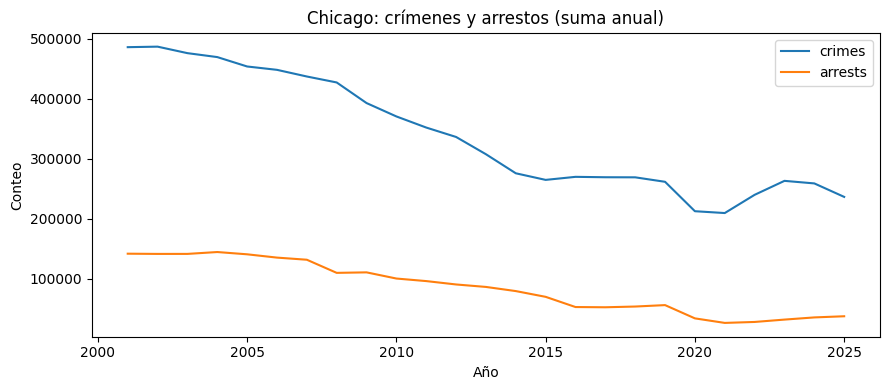

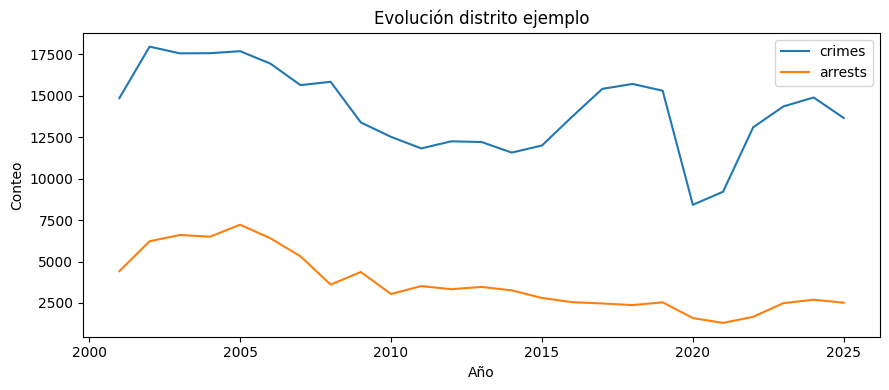

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# ¿Cuántos distritos y años?
print("Distritos:", df_yearly['district'].nunique(), " | Años:", df_yearly['year'].nunique())

# Tasa de arrestos (arrests / crimes) — ayuda a interpretar escalas distintas
df_yearly['arrest_rate'] = df_yearly['arrests'] / df_yearly['crimes']

# Evolución total anual (suma sobre distritos)
annual = df_yearly.groupby('year')[['crimes','arrests']].sum()
ax = annual.plot(kind='line', figsize=(9,4), title='Chicago: crímenes y arrestos (suma anual)')
ax.set_xlabel('Año'); ax.set_ylabel('Conteo')
plt.tight_layout(); plt.show()

# Evolución por un distrito de ejemplo (p. ej., distrito 1)
d1 = df_yearly[df_yearly['district'] == df_yearly['district'].unique()[0]]
ax = d1.plot(x='year', y=['crimes','arrests'], figsize=(9,4), title='Evolución distrito ejemplo')
ax.set_xlabel('Año'); ax.set_ylabel('Conteo')
plt.tight_layout(); plt.show()

In [29]:
import statsmodels.formula.api as smf

# Elimina la primera observación de cada distrito (donde arrests_lag1 es NaN)
panel = df_yearly.dropna(subset=['arrests_lag1']).copy()

# Convierte FE a categóricas
panel['district_fe'] = panel['district'].astype('category')
panel['year_fe'] = panel['year'].astype('category')

# Modelo con efectos fijos por distrito y año
model = smf.ols(
    formula="crimes ~ arrests_lag1 + C(district_fe) + C(year_fe)",
    data=panel
).fit(cov_type='cluster', cov_kwds={'groups': panel['district']})

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 crimes   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     390.4
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           1.19e-24
Time:                        21:26:28   Log-Likelihood:                -4758.3
No. Observations:                 552   AIC:                             9613.
Df Residuals:                     504   BIC:                             9820.
Df Model:                          47                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept               1.25

c:\Users\andaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 47, but rank is 22
  warnings.warn('covariance of constraints does not have full '


In [30]:
import numpy as np

panel['log_crimes'] = np.log1p(panel['crimes'])
panel['log_arrests_lag1'] = np.log1p(panel['arrests_lag1'])

model_log = smf.ols(
    formula="log_crimes ~ log_arrests_lag1 + C(district_fe) + C(year_fe)",
    data=panel
).fit(cov_type='cluster', cov_kwds={'groups': panel['district']})

print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:             log_crimes   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     1329.
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           9.49e-31
Time:                        21:27:04   Log-Likelihood:                 315.23
No. Observations:                 552   AIC:                            -534.5
Df Residuals:                     504   BIC:                            -327.4
Df Model:                          47                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  7

c:\Users\andaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 47, but rank is 22
  warnings.warn('covariance of constraints does not have full '


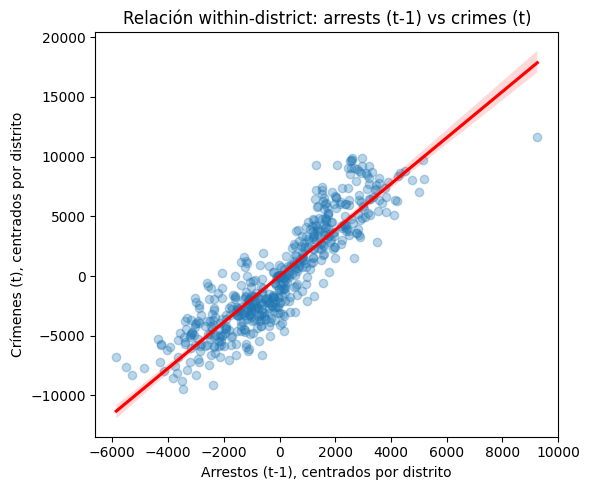

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Normaliza por distrito para ver relación interna (demeaned within)
w = panel.copy()
w['crimes_w'] = w['crimes'] - w.groupby('district')['crimes'].transform('mean')
w['arrests_lag1_w'] = w['arrests_lag1'] - w.groupby('district')['arrests_lag1'].transform('mean')

plt.figure(figsize=(6,5))
sns.regplot(data=w, x='arrests_lag1_w', y='crimes_w', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relación within-district: arrests (t-1) vs crimes (t)')
plt.xlabel('Arrestos (t-1), centrados por distrito')
plt.ylabel('Crímenes (t), centrados por distrito')
plt.tight_layout(); plt.show()

In [33]:
model = smf.ols(
    formula="crimes ~ arrests_lag1 + C(district) + C(year)",
    data=panel
).fit(cov_type='cluster', cov_kwds={'groups': panel['district']})

In [34]:
import pandas as pd
import statsmodels.formula.api as smf

# Punto de partida: df_yearly ya creado y ordenado
# columns = ['district','year','crimes','arrests','arrests_lag1', ...]
panel = df_yearly.sort_values(['district','year']).dropna(subset=['arrests_lag1']).copy()

# Efectos fijos como categóricas
panel['district_fe'] = panel['district'].astype('category')
panel['year_fe'] = panel['year'].astype('category')

# Modelo OLS con FE (dummies) y errores clusterizados por distrito
mod_fe = smf.ols(
    formula="crimes ~ arrests_lag1 + C(district_fe) + C(year_fe)",
    data=panel
).fit(cov_type='cluster', cov_kwds={'groups': panel['district']})

print(mod_fe.summary())

                            OLS Regression Results                            
Dep. Variable:                 crimes   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     390.4
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           1.19e-24
Time:                        21:30:59   Log-Likelihood:                -4758.3
No. Observations:                 552   AIC:                             9613.
Df Residuals:                     504   BIC:                             9820.
Df Model:                          47                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept               1.25

c:\Users\andaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 47, but rank is 22
  warnings.warn('covariance of constraints does not have full '


In [35]:
import numpy as np

panel['log_crimes'] = np.log1p(panel['crimes'])
panel['log_arrests_lag1'] = np.log1p(panel['arrests_lag1'])

mod_fe_log = smf.ols(
    formula="log_crimes ~ log_arrests_lag1 + C(district_fe) + C(year_fe)",
    data=panel
).fit(cov_type='cluster', cov_kwds={'groups': panel['district']})

print(mod_fe_log.summary())

                            OLS Regression Results                            
Dep. Variable:             log_crimes   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     1329.
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           9.49e-31
Time:                        21:31:33   Log-Likelihood:                 315.23
No. Observations:                 552   AIC:                            -534.5
Df Residuals:                     504   BIC:                            -327.4
Df Model:                          47                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  7

c:\Users\andaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 47, but rank is 22
  warnings.warn('covariance of constraints does not have full '


In [3]:
"""
============================================================================
EXPERIMENTO NATURAL: Demoliciones de Vivienda Pública y Crimen en Chicago
============================================================================
Diseño: Difference-in-Differences escalonado
Unidad de análisis: Community Area × Mes
Período: 2001–2010
============================================================================

INSTRUCCIONES:
- Ajusta la variable DATA_PATH al path de tu archivo parquet/csv
- Corre cada sección en celdas separadas en tu notebook
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats






In [5]:

# Normalizar nombres de columna
df.columns = [c.strip().lower() for c in df.columns]

# Parsear fecha
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Filtrar período de estudio (2001-2010 para captar demoliciones completas)
df = df[(df['year'] >= 2001) & (df['year'] <= 2010)].copy()

# Remover filas sin community_area o con community_area = 0
df = df[df['community_area'].notna() & (df['community_area'] > 0)].copy()
df['community_area'] = df['community_area'].astype(int)

# Crear variable de mes
df['month'] = df['date'].dt.to_period('M')

print(f"Registros: {len(df):,}")
print(f"Período: {df['year'].min()} - {df['year'].max()}")
print(f"Community Areas: {df['community_area'].nunique()}")
print(f"Meses: {df['month'].nunique()}")

Registros: 3,834,675
Período: 2001 - 2010
Community Areas: 77
Meses: 120


In [6]:
print(df['district'].nunique())
print(df['district'].unique())

24
[17. 25. 16.  9. 22.  2.  8. 18. 10. 11.  6. 12. 20.  4.  7.  5. 14. 24.
  1. 15.  3. 19. 31. 21. nan]


In [7]:
import pandas as pd
import os

folder = "data/chicago_crime_data/"
for f in os.listdir(folder):
    size = os.path.getsize(os.path.join(folder, f))
    print(f"{f}: {size/1e6:.1f} MB")

df = pd.read_csv("data/chicago_crime_data/chicago_crimes_2001_2025.csv", nrows=5, low_memory=False)

print("\n── COLUMNAS ──")
print(df.columns.tolist())

print("\n── TIPOS ──")
print(df.dtypes)

print("\n── EJEMPLO DATE ──")
print(df['date'].head(3).tolist())

print("\n── EJEMPLO ARREST ──")
print(df['arrest'].head(3).tolist() if 'arrest' in df.columns else "NO EXISTE")

print("\n── EJEMPLO COMMUNITY_AREA ──")
print(df['community_area'].head(3).tolist() if 'community_area' in df.columns else "NO EXISTE")

print("\n── EJEMPLO PRIMARY_TYPE ──")
print(df['primary_type'].head(3).tolist() if 'primary_type' in df.columns else "NO EXISTE")

batches: 0.1 MB
chicago_2001_2025.parquet: 583.9 MB
chicago_crimes.parquet: 603.2 MB
chicago_crimes_2001_2025.csv: 3075.1 MB
chicago_crimes_2001_2025.parquet: 0.0 MB

── COLUMNAS ──
['id', 'case_number', 'date', 'block', 'iucr', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'beat', 'district', 'ward', 'community_area', 'fbi_code', 'year', 'updated_on', 'x_coordinate', 'y_coordinate', 'latitude', 'longitude', 'location']

── TIPOS ──
id                        int64
case_number                 str
date                        str
block                       str
iucr                      int64
primary_type                str
description                 str
location_description        str
arrest                     bool
domestic                   bool
beat                      int64
district                float64
ward                    float64
community_area          float64
fbi_code                  int64
year                      int64
updated_on          

In [8]:
import pandas as pd
import numpy as np

# ── Cargar datos ──
df = pd.read_parquet("data/chicago_crime_data/chicago_2001_2025.parquet")

# ── Parsear fecha (formato ISO, funciona directo) ──
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# ── Filtrar período de estudio: 2001–2010 ──
df = df[(df['year'] >= 2001) & (df['year'] <= 2010)].copy()

# ── Limpiar community_area (viene como float, pasarla a int, quitar NaN y 0) ──
df = df[df['community_area'].notna() & (df['community_area'] > 0)].copy()
df['community_area'] = df['community_area'].astype(int)

# ── Arrest: viene como bool (True/False), convertir a 1/0 ──
df['arrest'] = df['arrest'].astype(int)

# ── Crear columna de mes ──
df['month'] = df['date'].dt.to_period('M')

# ── Verificación ──
print(f"Registros: {len(df):,}")
print(f"Período: {df['year'].min()} – {df['year'].max()}")
print(f"Community Areas: {df['community_area'].nunique()}")
print(f"Distritos: {df['district'].nunique()}")
print(f"Meses: {df['month'].nunique()}")
print(f"\nTipos de crimen más frecuentes:")
print(df['primary_type'].value_counts().head(10))
print(f"\nArrestos: {df['arrest'].sum():,} de {len(df):,} ({df['arrest'].mean()*100:.1f}%)")

Registros: 3,834,675
Período: 2001 – 2010
Community Areas: 77
Distritos: 24
Meses: 120

Tipos de crimen más frecuentes:
primary_type
THEFT                  773201
BATTERY                698759
CRIMINAL DAMAGE        455119
NARCOTICS              446350
OTHER OFFENSE          239515
ASSAULT                230606
BURGLARY               222927
MOTOR VEHICLE THEFT    181771
ROBBERY                141450
DECEPTIVE PRACTICE     120631
Name: count, dtype: int64

Arrestos: 1,116,028 de 3,834,675 (29.1%)


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# PASO 2: DEFINIR GRUPOS DE TRATAMIENTO
# ═══════════════════════════════════════════════════════════════════════════

# CAs donde se demolieron proyectos (CA, nombre, fecha inicio demolición)
demolitions = {
    8:  ("Cabrini-Green / Near North",              "2000-01-01"),
    27: ("Rockwell Gardens / E. Garfield Park",     "2003-06-01"),
    28: ("ABLA Homes / Near West Side",             "2002-06-01"),
    38: ("Stateway Gardens + R.Taylor / Grand Blvd", "2001-06-01"),
    40: ("Robert Taylor / Washington Park",          "2005-01-01"),
}

# CAs vecinas (potencial spillover)
spillover_cas = [24, 32, 26, 29, 25, 35, 37, 39, 41, 69]

# CAs de control (sin vivienda pública, no contiguas)
control_cas = [10, 12, 13, 14, 16, 17, 76, 77, 9, 19, 56, 58, 59, 72, 73, 74, 75]

def assign_group(ca):
    if ca in demolitions:
        return "tratamiento"
    elif ca in spillover_cas:
        return "spillover"
    elif ca in control_cas:
        return "control"
    else:
        return "otro"

df['group'] = df['community_area'].apply(assign_group)

print("Crímenes por grupo:")
print(df['group'].value_counts())
print(f"\nCAs tratamiento: {sorted(demolitions.keys())}")
print(f"CAs spillover:   {sorted(spillover_cas)}")
print(f"CAs control:     {sorted(control_cas)}")

# ═══════════════════════════════════════════════════════════════════════════
# PASO 3: CONSTRUIR PANEL community_area × mes
# ═══════════════════════════════════════════════════════════════════════════

# Clasificar tipos de crimen
violent_crimes = ['HOMICIDE', 'ASSAULT', 'BATTERY', 'ROBBERY',
                  'CRIM SEXUAL ASSAULT', 'KIDNAPPING']
property_crimes = ['THEFT', 'BURGLARY', 'MOTOR VEHICLE THEFT', 'ARSON']

df['is_violent'] = df['primary_type'].isin(violent_crimes).astype(int)
df['is_property'] = df['primary_type'].isin(property_crimes).astype(int)
df['is_narcotics'] = (df['primary_type'] == 'NARCOTICS').astype(int)

# Crímenes en vía pública vs interiores
outdoor_locs = ['STREET', 'SIDEWALK', 'ALLEY', 'PARKING LOT/GARAGE(NON.RESID.)',
                'PARK PROPERTY', 'VACANT LOT/LAND', 'GAS STATION']
df['is_outdoor'] = df['location_description'].isin(outdoor_locs).astype(int)

# Agregar panel
panel = (
    df.groupby(['community_area', 'month', 'group'])
    .agg(
        crimes=('id', 'count'),
        arrests=('arrest', 'sum'),
        violent=('is_violent', 'sum'),
        property_c=('is_property', 'sum'),
        narcotics=('is_narcotics', 'sum'),
        outdoor_crimes=('is_outdoor', 'sum'),
    )
    .reset_index()
)

panel['arrest_rate'] = panel['arrests'] / panel['crimes']
panel['month_dt'] = panel['month'].dt.to_timestamp()

print(f"\nPanel construido: {panel.shape[0]} filas (CA × mes)")
print(f"Columnas: {panel.columns.tolist()}")
print(panel.head())

Crímenes por grupo:
group
otro           2159597
spillover       808847
control         461891
tratamiento     404340
Name: count, dtype: int64

CAs tratamiento: [8, 27, 28, 38, 40]
CAs spillover:   [24, 25, 26, 29, 32, 35, 37, 39, 41, 69]
CAs control:     [9, 10, 12, 13, 14, 16, 17, 19, 56, 58, 59, 72, 73, 74, 75, 76, 77]

Panel construido: 9120 filas (CA × mes)
Columnas: ['community_area', 'month', 'group', 'crimes', 'arrests', 'violent', 'property_c', 'narcotics', 'outdoor_crimes', 'arrest_rate', 'month_dt']
   community_area    month group  crimes  arrests  violent  property_c  \
0               1  2001-01  otro      11        2        0           4   
1               1  2001-02  otro       3        0        1           0   
2               1  2001-03  otro       4        1        1           2   
3               1  2001-04  otro       5        1        1           2   
4               1  2001-05  otro       3        0        0           1   

   narcotics  outdoor_crimes  arrest_r

In [11]:
import matplotlib.pyplot as plt

Variables de tratamiento:
  post_demol = 1:     501 obs
  post_spillover = 1: 1009 obs
  Ambos = 0:          7610 obs

Detalle por CA tratada:
  CA 8 (Cabrini-Green / Near North): 120 meses post, 0 meses pre
  CA 27 (Rockwell Gardens / E. Garfield Park): 91 meses post, 29 meses pre
  CA 28 (ABLA Homes / Near West Side): 103 meses post, 17 meses pre
  CA 38 (Stateway Gardens + R.Taylor / Grand Blvd): 115 meses post, 5 meses pre
  CA 40 (Robert Taylor / Washington Park): 72 meses post, 48 meses pre


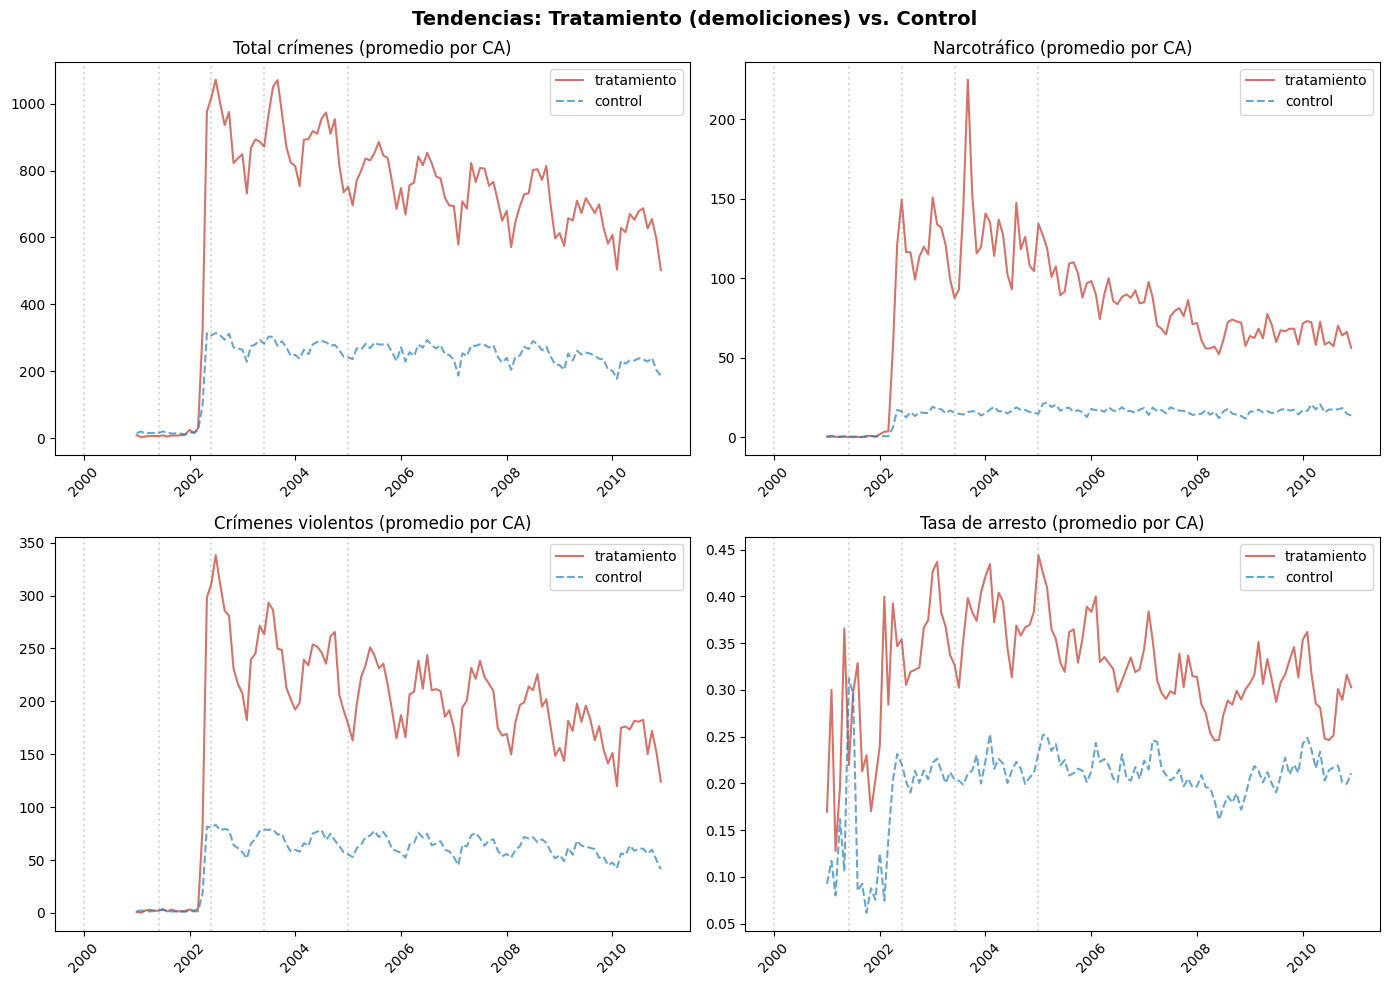


── Promedios pre vs. post por grupo ──
  tratamiento: pre=264.2  post=754.9  cambio=490.7 (185.8%)
  control: pre=124.4  post=254.9  cambio=130.5 (105.0%)


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# PASO 4: CREAR VARIABLES DE TRATAMIENTO (DiD)
# ═══════════════════════════════════════════════════════════════════════════

# Fecha de demolición por CA tratada
def get_demol_date(ca):
    if ca in demolitions:
        return pd.Timestamp(demolitions[ca][1])
    return pd.NaT

panel['demol_date'] = panel['community_area'].apply(get_demol_date)

# post_demol = 1 si CA tratada Y ya pasó la fecha de demolición
panel['post_demol'] = (
    (panel['group'] == 'tratamiento') &
    (panel['month_dt'] >= panel['demol_date'])
).astype(int)

# Spillover: fecha de demolición de la CA tratada vecina más cercana
spillover_dates = {
    24: "2000-01-01", 32: "2000-01-01",   # vecinas de CA 8
    26: "2003-06-01", 29: "2003-06-01",   # vecinas de CA 27
    25: "2002-06-01",                       # vecina de CA 28
    35: "2001-06-01", 37: "2001-06-01",   # vecinas de CA 38
    39: "2001-06-01", 41: "2005-01-01",   # vecinas de CA 38/40
    69: "2005-01-01",                       # vecina de CA 40
}

def get_spillover_date(ca):
    if ca in spillover_dates:
        return pd.Timestamp(spillover_dates[ca])
    return pd.NaT

panel['spillover_date'] = panel['community_area'].apply(get_spillover_date)
panel['post_spillover'] = (
    (panel['group'] == 'spillover') &
    (panel['month_dt'] >= panel['spillover_date'])
).astype(int)

print("Variables de tratamiento:")
print(f"  post_demol = 1:     {panel['post_demol'].sum()} obs")
print(f"  post_spillover = 1: {panel['post_spillover'].sum()} obs")
print(f"  Ambos = 0:          {((panel['post_demol']==0) & (panel['post_spillover']==0)).sum()} obs")

# Verificar que tiene sentido
print("\nDetalle por CA tratada:")
for ca, (name, date) in demolitions.items():
    sub = panel[panel['community_area'] == ca]
    print(f"  CA {ca} ({name}): {sub['post_demol'].sum()} meses post, {len(sub) - sub['post_demol'].sum()} meses pre")


# ═══════════════════════════════════════════════════════════════════════════
# PASO 5: ESTADÍSTICA DESCRIPTIVA — Tendencias paralelas visual
# ═══════════════════════════════════════════════════════════════════════════

viz = panel[panel['group'].isin(['tratamiento', 'control'])].copy()

ts = viz.groupby(['month_dt', 'group']).agg(
    avg_crimes=('crimes', 'mean'),
    avg_narcotics=('narcotics', 'mean'),
    avg_violent=('violent', 'mean'),
    avg_arrest_rate=('arrest_rate', 'mean'),
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Tendencias: Tratamiento (demoliciones) vs. Control', fontsize=14, fontweight='bold')

for ax, var, title in zip(
    axes.flat,
    ['avg_crimes', 'avg_narcotics', 'avg_violent', 'avg_arrest_rate'],
    ['Total crímenes (promedio por CA)',
     'Narcotráfico (promedio por CA)',
     'Crímenes violentos (promedio por CA)',
     'Tasa de arresto (promedio por CA)']
):
    for grp, color, ls in [('tratamiento', '#c0392b', '-'), ('control', '#2980b9', '--')]:
        sub = ts[ts['group'] == grp]
        ax.plot(sub['month_dt'], sub[var], color=color, linestyle=ls, alpha=0.7, label=grp)

    # Líneas verticales para cada demolición
    for ca, (name, date) in demolitions.items():
        ax.axvline(pd.Timestamp(date), color='gray', alpha=0.3, linestyle=':')

    ax.set_title(title)
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n── Promedios pre vs. post por grupo ──")
for grp in ['tratamiento', 'control']:
    sub = panel[panel['group'] == grp]
    if grp == 'tratamiento':
        pre = sub[sub['post_demol'] == 0]['crimes'].mean()
        post = sub[sub['post_demol'] == 1]['crimes'].mean()
    else:
        pre = sub[sub['month_dt'] < '2003-01-01']['crimes'].mean()
        post = sub[sub['month_dt'] >= '2003-01-01']['crimes'].mean()
    print(f"  {grp}: pre={pre:.1f}  post={post:.1f}  cambio={post-pre:.1f} ({(post-pre)/pre*100:.1f}%)")

In [13]:
# Ajustar fechas de demolición al período donde realmente se intensificó
# la demolición dentro de nuestra ventana de datos (2001-2010)
demolitions[8] = ("Cabrini-Green / Near North", "2002-06-01")  # ext. completada 2002
demolitions[38] = ("Stateway Gardens + R.Taylor / Grand Blvd", "2002-01-01")  # dar más pre

# Recalcular post_demol
panel['demol_date'] = panel['community_area'].apply(get_demol_date)
panel['post_demol'] = (
    (panel['group'] == 'tratamiento') &
    (panel['month_dt'] >= panel['demol_date'])
).astype(int)

# Recalcular spillover también
spillover_dates[24] = "2002-06-01"  # vecinas de CA 8
spillover_dates[32] = "2002-06-01"
spillover_dates[35] = "2002-01-01"  # vecinas de CA 38
spillover_dates[37] = "2002-01-01"
spillover_dates[39] = "2002-01-01"

panel['spillover_date'] = panel['community_area'].apply(get_spillover_date)
panel['post_spillover'] = (
    (panel['group'] == 'spillover') &
    (panel['month_dt'] >= panel['spillover_date'])
).astype(int)

# Verificar de nuevo
print("Detalle corregido por CA tratada:")
for ca, (name, date) in demolitions.items():
    sub = panel[panel['community_area'] == ca]
    print(f"  CA {ca}: {len(sub) - sub['post_demol'].sum()} meses pre, {sub['post_demol'].sum()} meses post")

Detalle corregido por CA tratada:
  CA 8: 17 meses pre, 103 meses post
  CA 27: 29 meses pre, 91 meses post
  CA 28: 17 meses pre, 103 meses post
  CA 38: 12 meses pre, 108 meses post
  CA 40: 48 meses pre, 72 meses post


In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# CORRECCIÓN: quitar primeros meses de 2001 (datos incompletos)
# ═══════════════════════════════════════════════════════════════════════════
panel = panel[panel['month_dt'] >= '2001-04-01'].copy()
print(f"Panel después de corte: {len(panel)} filas, desde {panel['month_dt'].min()}")

# ═══════════════════════════════════════════════════════════════════════════
# PASO 6: ESTIMACIÓN DiD PRINCIPAL
# ═══════════════════════════════════════════════════════════════════════════
import statsmodels.formula.api as smf

did_data = panel[panel['group'].isin(['tratamiento', 'control'])].copy()
did_data['ca_fe'] = did_data['community_area'].astype('category')
did_data['month_str'] = did_data['month'].astype(str)

# ── Modelo 1: Crimen total ──
print("=" * 60)
print("MODELO 1: Efecto sobre crimen total")
print("=" * 60)
mod1 = smf.ols(
    "crimes ~ post_demol + C(ca_fe) + C(month_str)",
    data=did_data
).fit(cov_type='cluster', cov_kwds={'groups': did_data['community_area']})

beta = mod1.params['post_demol']
se = mod1.bse['post_demol']
pval = mod1.pvalues['post_demol']
ci = mod1.conf_int().loc['post_demol']
print(f"  β = {beta:.2f} crímenes/mes")
print(f"  SE = {se:.2f}")
print(f"  p-value = {pval:.4f}")
print(f"  95% CI = [{ci[0]:.2f}, {ci[1]:.2f}]")
print(f"  N = {int(mod1.nobs)}")

# ── Modelo 2: Narcotráfico ──
print("\n" + "=" * 60)
print("MODELO 2: Efecto sobre narcotráfico")
print("=" * 60)
mod2 = smf.ols(
    "narcotics ~ post_demol + C(ca_fe) + C(month_str)",
    data=did_data
).fit(cov_type='cluster', cov_kwds={'groups': did_data['community_area']})
print(f"  β = {mod2.params['post_demol']:.2f}")
print(f"  p-value = {mod2.pvalues['post_demol']:.4f}")

# ── Modelo 3: Crímenes violentos ──
print("\n" + "=" * 60)
print("MODELO 3: Efecto sobre crímenes violentos")
print("=" * 60)
mod3 = smf.ols(
    "violent ~ post_demol + C(ca_fe) + C(month_str)",
    data=did_data
).fit(cov_type='cluster', cov_kwds={'groups': did_data['community_area']})
print(f"  β = {mod3.params['post_demol']:.2f}")
print(f"  p-value = {mod3.pvalues['post_demol']:.4f}")

# ── Modelo 4: Tasa de arresto ──
print("\n" + "=" * 60)
print("MODELO 4: Efecto sobre tasa de arresto")
print("=" * 60)
mod4 = smf.ols(
    "arrest_rate ~ post_demol + C(ca_fe) + C(month_str)",
    data=did_data
).fit(cov_type='cluster', cov_kwds={'groups': did_data['community_area']})
print(f"  β = {mod4.params['post_demol']:.4f}")
print(f"  p-value = {mod4.pvalues['post_demol']:.4f}")

# ── Resumen ──
print("\n" + "=" * 60)
print("RESUMEN")
print("=" * 60)
for name, mod in [("Crimen total", mod1), ("Narcotráfico", mod2), 
                   ("Violentos", mod3), ("Tasa arresto", mod4)]:
    b = mod.params['post_demol']
    p = mod.pvalues['post_demol']
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f"  {name:20s}  β = {b:>8.3f}   p = {p:.4f} {sig}")

Panel después de corte: 8926 filas, desde 2001-04-01 00:00:00
MODELO 1: Efecto sobre crimen total
  β = 291.48 crímenes/mes
  SE = 138.26
  p-value = 0.0350
  95% CI = [20.49, 562.47]
  N = 2546

MODELO 2: Efecto sobre narcotráfico
  β = 35.37
  p-value = 0.0071

MODELO 3: Efecto sobre crímenes violentos
  β = 66.47
  p-value = 0.0320

MODELO 4: Efecto sobre tasa de arresto
  β = 0.0022
  p-value = 0.8819

RESUMEN
  Crimen total          β =  291.483   p = 0.0350 **
  Narcotráfico          β =   35.371   p = 0.0071 ***
  Violentos             β =   66.472   p = 0.0320 **
  Tasa arresto          β =    0.002   p = 0.8819 


In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# DIAGNÓSTICO: ¿Qué está pasando por CA?
# ═══════════════════════════════════════════════════════════════════════════

print("── Promedio de crímenes/mes: PRE vs POST por CA tratada ──\n")
for ca, (name, date) in demolitions.items():
    sub = panel[panel['community_area'] == ca]
    pre = sub[sub['post_demol'] == 0]['crimes']
    post = sub[sub['post_demol'] == 1]['crimes']
    print(f"CA {ca} ({name}):")
    print(f"  Pre:  {len(pre)} meses, promedio = {pre.mean():.1f}")
    print(f"  Post: {len(post)} meses, promedio = {post.mean():.1f}")
    print(f"  Cambio: {post.mean() - pre.mean():.1f}\n")

print("\n── Promedio de crímenes/mes: PRE vs POST controles ──")
ctrl = panel[panel['group'] == 'control']
pre_c = ctrl[ctrl['month_dt'] < '2003-01-01']['crimes']
post_c = ctrl[ctrl['month_dt'] >= '2003-01-01']['crimes']
print(f"  Pre:  promedio = {pre_c.mean():.1f}")
print(f"  Post: promedio = {post_c.mean():.1f}")
print(f"  Cambio: {post_c.mean() - pre_c.mean():.1f}")

# ── Ver si el problema es el inicio de los datos ──
print("\n── Crímenes promedio por CA tratada en primeros meses ──")
for ca, (name, _) in demolitions.items():
    sub = panel[panel['community_area'] == ca].sort_values('month_dt').head(12)
    print(f"\nCA {ca} ({name}) — primeros 12 meses:")
    print(sub[['month_dt', 'crimes', 'narcotics', 'violent']].to_string(index=False))

── Promedio de crímenes/mes: PRE vs POST por CA tratada ──

CA 8 (Cabrini-Green / Near North):
  Pre:  14 meses, promedio = 160.0
  Post: 103 meses, promedio = 1182.6
  Cambio: 1022.6

CA 27 (Rockwell Gardens / E. Garfield Park):
  Pre:  26 meses, promedio = 381.9
  Post: 91 meses, promedio = 684.8
  Cambio: 302.9

CA 28 (ABLA Homes / Near West Side):
  Pre:  14 meses, promedio = 131.1
  Post: 103 meses, promedio = 1052.9
  Cambio: 921.7

CA 38 (Stateway Gardens + R.Taylor / Grand Blvd):
  Pre:  9 meses, promedio = 5.0
  Post: 108 meses, promedio = 518.0
  Cambio: 513.0

CA 40 (Robert Taylor / Washington Park):
  Pre:  45 meses, promedio = 317.9
  Post: 72 meses, promedio = 380.4
  Cambio: 62.4


── Promedio de crímenes/mes: PRE vs POST controles ──
  Pre:  promedio = 137.5
  Post: promedio = 254.9
  Cambio: 117.4

── Crímenes promedio por CA tratada en primeros meses ──

CA 8 (Cabrini-Green / Near North) — primeros 12 meses:
  month_dt  crimes  narcotics  violent
2001-04-01      13   